# 🛒 Customer Segmentation Using K-Means Clustering

---

## 📌 Introduction

In this project, we use **K-Means Clustering** — an unsupervised machine learning algorithm — to segment mall customers into distinct groups based on their:
- **Age**
- **Annual Income**
- **Spending Score**

### 🎯 Goal
By grouping customers with similar behavior, businesses can:
- Design targeted marketing campaigns
- Improve customer experience
- Boost sales by understanding different customer types

### 📂 Dataset
We use the **Mall Customers dataset** (`Mall_Customers.csv`) which contains basic purchase data collected from a mall's membership cards.

| Column | Description |
|--------|-------------|
| CustomerID | Unique customer identifier |
| Gender | Male or Female |
| Age | Age of the customer |
| Annual Income (k$) | Annual income in thousands of dollars |
| Spending Score (1-100) | Score assigned by the mall (1 = low spender, 100 = high spender) |

---
## 📦 Step 1: Import Required Libraries

In [12]:
# Core data manipulation libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning — K-Means from scikit-learn
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# For 3D plotting
from mpl_toolkits.mplot3d import Axes3D

# Suppress unnecessary warnings for clean output
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 📂 Step 2: Load the Dataset

In [13]:
# Load the dataset from CSV file
# Make sure 'Mall_Customers.csv' is in the same folder as this notebook
df = pd.read_csv('Mall_Customers.csv')

# Display the first 5 rows to get a quick look at the data
print(f"Dataset loaded! Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df.head()

Dataset loaded! Shape: 200 rows × 5 columns



,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [14]:
print(df.columns)

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [15]:
# Rename column (recommended)
df.rename(columns={'Genre': 'Gender'}, inplace=True)

# Now encode
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

print("✅ Gender encoded successfully")

✅ Gender encoded successfully


---
## 🔍 Step 3: Basic Data Exploration

In [16]:
# Check the shape — how many rows and columns do we have?
print(f"Shape of dataset: {df.shape}")
print(f"  → {df.shape[0]} customers")
print(f"  → {df.shape[1]} features")

Shape of dataset: (200, 5)
  → 200 customers
  → 5 features


In [17]:
# Check column names and data types
# This tells us what kind of data each column holds (numbers, text, etc.)
print("Column Info:")
df.info()

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    int64
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


In [18]:
# Statistical summary of all numeric columns
# Shows min, max, mean, std, quartiles — very useful for understanding the data range
print("Statistical Summary:")
df.describe().round(2)

Statistical Summary:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00,200.00
mean,100.50,0.56,38.85,60.56,50.20
std,57.88,0.50,13.97,26.26,25.82
min,1.00,0.00,18.00,15.00,1.00
25%,50.75,0.00,28.75,41.50,34.75
50%,100.50,1.00,36.00,61.50,50.00
75%,150.25,1.00,49.00,78.00,73.00
max,200.00,1.00,70.00,137.00,99.00


---
## 🧹 Step 4: Data Preprocessing

In [19]:
# --- Check for Missing Values ---
# Missing values can cause errors during model training, so we check first
print("Missing Values per Column:")
print(df.isnull().sum())
print()

if df.isnull().sum().sum() == 0:
    print("✅ Great! No missing values found. The dataset is clean.")
else:
    print("⚠️ Missing values found. Filling with column median...")
    df.fillna(df.median(numeric_only=True), inplace=True)

Missing Values per Column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

✅ Great! No missing values found. The dataset is clean.


In [20]:
# --- Remove Unnecessary Column ---
# 'CustomerID' is just an identifier — it has no useful information for clustering
df.drop(['CustomerID'], axis=1, inplace=True)

print("✅ 'CustomerID' column removed.")
print(f"\nRemaining columns: {list(df.columns)}")
df.head()

✅ 'CustomerID' column removed.

Remaining columns: ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [21]:
# --- Encode Gender Column ---
# Convert Gender to numeric (Male = 0, Female = 1)

df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Check if any values were not mapped (important safety check)
if df['Gender'].isnull().sum() > 0:
    print("⚠️ Warning: Some values in 'Gender' were not mapped!")

print("✅ Gender encoded successfully: Male = 0, Female = 1")

# Display counts
print("\nGender value counts:")
print(df['Gender'].value_counts())

⚠️ Warning: Some values in 'Gender' were not mapped!
✅ Gender encoded successfully: Male = 0, Female = 1

Gender value counts:
Series([], Name: count, dtype: int64)


---
## 📊 Step 5: Exploratory Data Analysis (EDA)

Before building the model, let's visually explore the data to understand its distribution and patterns.

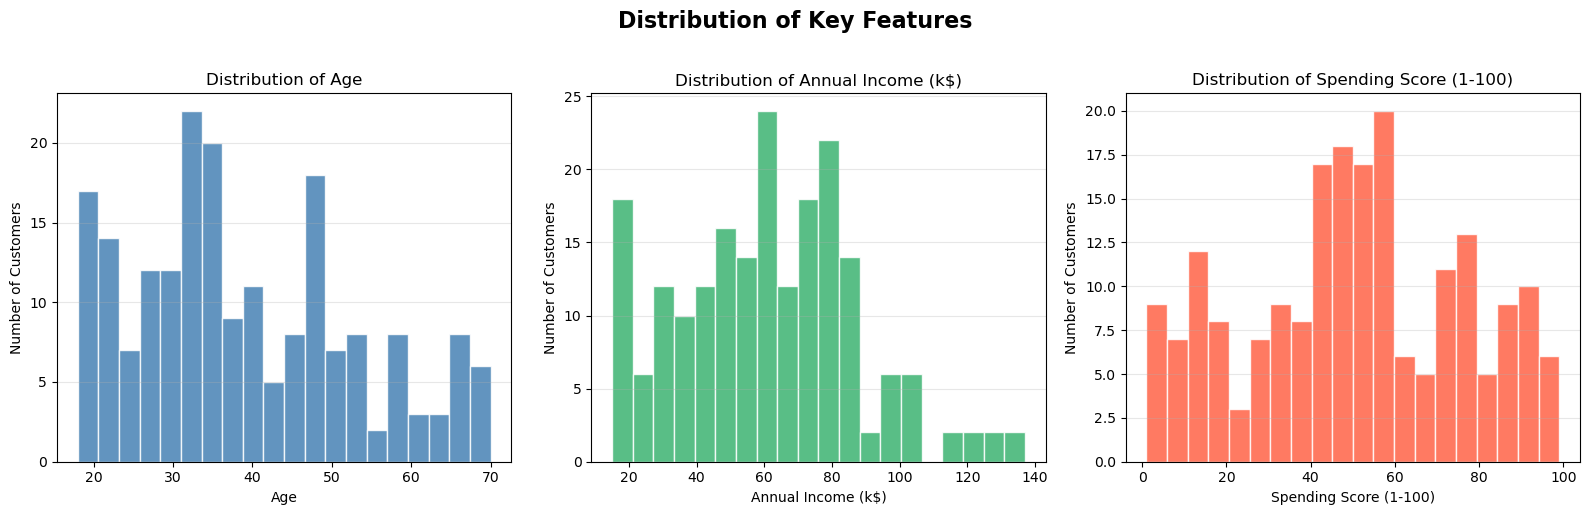

In [22]:
# --- Distribution Plots for Numeric Features ---
# A distribution plot shows how values are spread across a range

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution of Key Features', fontsize=16, fontweight='bold', y=1.02)

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors = ['steelblue', 'mediumseagreen', 'tomato']

for ax, feature, color in zip(axes, features, colors):
    ax.hist(df[feature], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribution of {feature}', fontsize=12)
    ax.set_xlabel(feature)
    ax.set_ylabel('Number of Customers')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

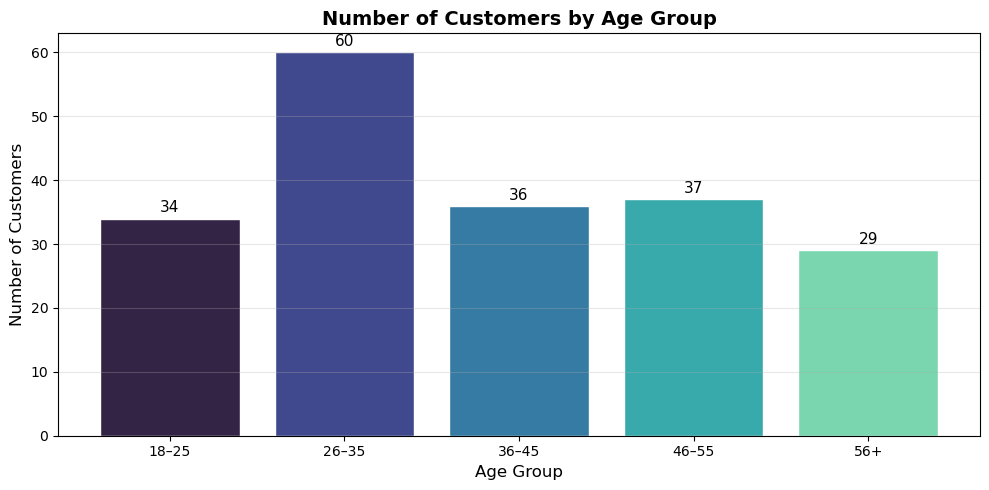

In [23]:
# --- Age Group Analysis ---
# Group customers into age brackets and see how many fall in each group

age_bins = [18, 25, 35, 45, 55, 70]
age_labels = ['18–25', '26–35', '36–45', '46–55', '56+']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=True)

age_counts = df['Age Group'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(age_counts.index, age_counts.values, color=sns.color_palette('mako', len(age_counts)), edgecolor='white')
plt.title('Number of Customers by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add value labels on top of each bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Remove the temp column
df.drop('Age Group', axis=1, inplace=True)

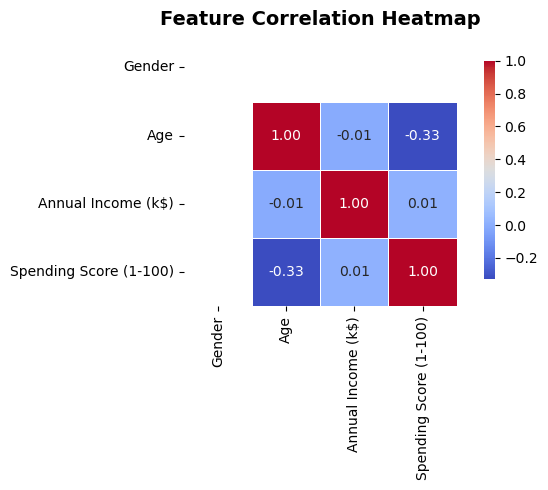

In [24]:
# --- Correlation Heatmap ---
# A heatmap helps us understand which features are related to each other
# Values close to 1 or -1 mean strong correlation; values near 0 mean no relation

plt.figure(figsize=(7, 5))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

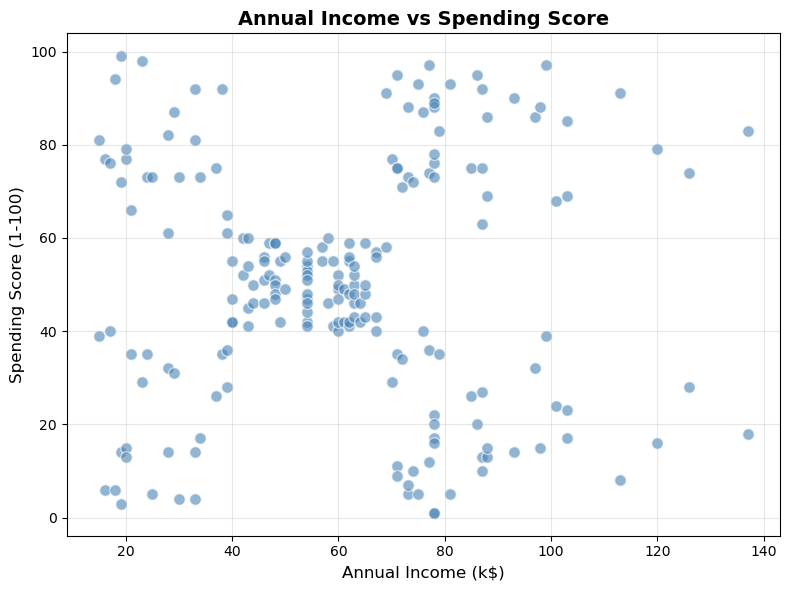

💡 Observation: You can already see roughly 5 natural groupings of customers!


In [25]:
# --- Scatter Plot: Annual Income vs Spending Score ---
# This is the most important pair for clustering — let's see if natural groups exist

plt.figure(figsize=(8, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            alpha=0.6, color='steelblue', edgecolors='white', s=70)
plt.title('Annual Income vs Spending Score', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Observation: You can already see roughly 5 natural groupings of customers!")

---
## 📐 Step 6: Feature Selection & Scaling

We will run two clustering experiments:
1. **2D Clustering** — using `Annual Income` and `Spending Score` (easiest to visualize)
2. **3D Clustering** — using `Age`, `Annual Income`, and `Spending Score`

In [26]:
# Select the two main features for 2D clustering
X2 = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Select three features for 3D clustering
X3 = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

# --- Feature Scaling ---
# K-Means uses distance to form clusters. If features are on different scales
# (e.g., income in thousands vs score in 1-100), the larger values dominate.
# StandardScaler brings all features to a similar range (mean=0, std=1).

scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)
X3_scaled = scaler.fit_transform(X3)

print(f"✅ 2D feature matrix shape: {X2_scaled.shape}")
print(f"✅ 3D feature matrix shape: {X3_scaled.shape}")

✅ 2D feature matrix shape: (200, 2)
✅ 3D feature matrix shape: (200, 3)


---
## 📈 Step 7: Elbow Method — Finding the Optimal Number of Clusters

The **Elbow Method** helps us choose the best value of **K** (number of clusters).

- We train K-Means for K = 1 to 10
- For each K, we record the **WCSS** (Within-Cluster Sum of Squares) — how tightly packed the clusters are
- The "elbow" in the plot is where adding more clusters stops giving significant improvement
- We pick K at that elbow point

  File "C:\Users\Rhea Chetiwal\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Rhea Chetiwal\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Rhea Chetiwal\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Rhea Ch

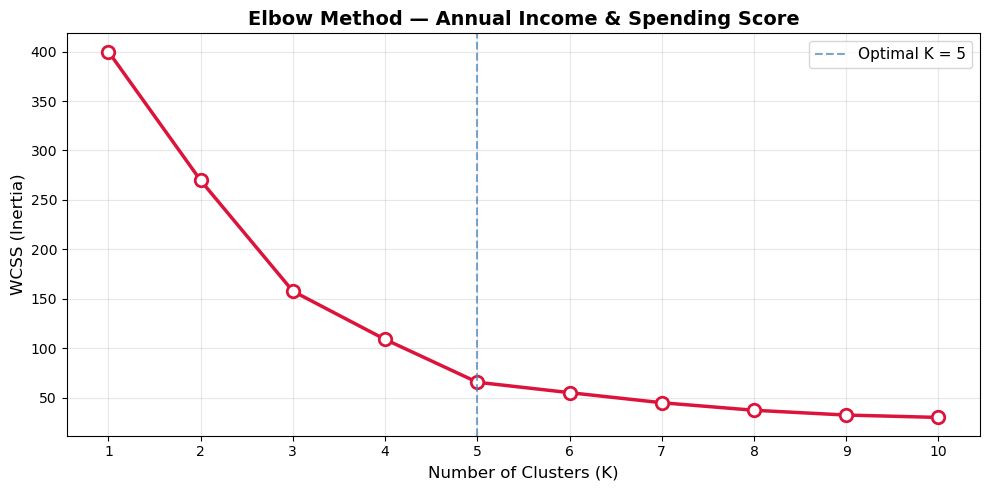

💡 The elbow appears at K = 5. That's our optimal number of clusters for 2D.


In [27]:
# --- Elbow Method for 2D Clustering (Income vs Spending Score) ---

wcss_2d = []

# Try K from 1 to 10 and record WCSS (inertia) for each
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X2_scaled)
    wcss_2d.append(kmeans.inertia_)  # inertia_ = WCSS

# Plot the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss_2d, marker='o', linewidth=2.5, color='crimson',
         markerfacecolor='white', markeredgewidth=2, markersize=9)
plt.axvline(x=5, color='steelblue', linestyle='--', alpha=0.7, label='Optimal K = 5')
plt.title('Elbow Method — Annual Income & Spending Score', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(range(1, 11))
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 The elbow appears at K = 5. That's our optimal number of clusters for 2D.")

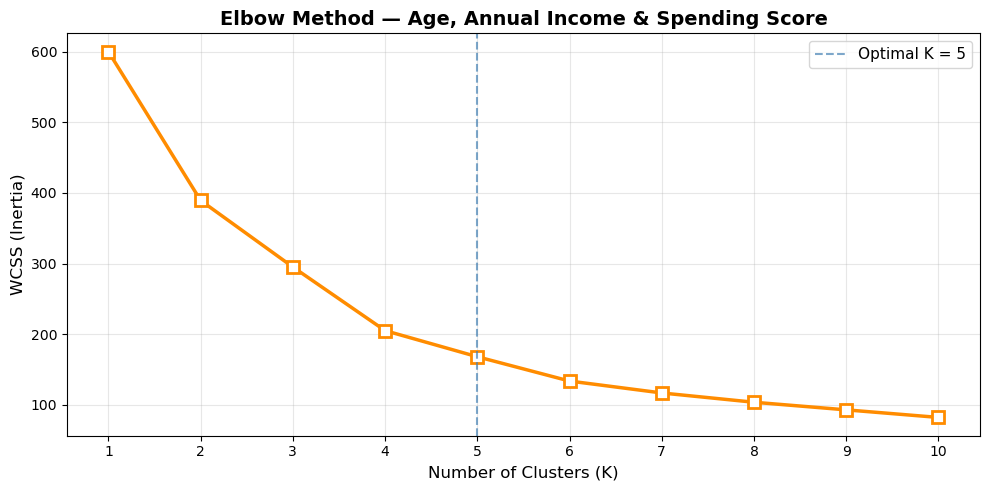

💡 For the 3D case, the elbow also appears around K = 5.


In [28]:
# --- Elbow Method for 3D Clustering (Age + Income + Spending Score) ---

wcss_3d = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X3_scaled)
    wcss_3d.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss_3d, marker='s', linewidth=2.5, color='darkorange',
         markerfacecolor='white', markeredgewidth=2, markersize=9)
plt.axvline(x=5, color='steelblue', linestyle='--', alpha=0.7, label='Optimal K = 5')
plt.title('Elbow Method — Age, Annual Income & Spending Score', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(range(1, 11))
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 For the 3D case, the elbow also appears around K = 5.")

---
## 🤖 Step 8: Apply K-Means Clustering

Now that we know **K = 5** is optimal, we apply K-Means with that value.

In [29]:
# --- 2D K-Means: Annual Income & Spending Score ---
# n_clusters=5 → we want 5 groups
# init='k-means++' → smarter initialization (better results than random)
# random_state=42 → ensures reproducibility

kmeans_2d = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
labels_2d = kmeans_2d.fit_predict(X2_scaled)

# Assign cluster labels to the dataframe
df['Cluster_2D'] = labels_2d

print("✅ 2D K-Means applied successfully!")
print(f"\nCluster sizes:")
print(df['Cluster_2D'].value_counts().sort_index().rename('Customer Count'))

✅ 2D K-Means applied successfully!

Cluster sizes:
Cluster_2D
0    81
1    39
2    22
3    35
4    23
Name: Customer Count, dtype: int64


In [30]:
# --- 3D K-Means: Age, Annual Income & Spending Score ---

kmeans_3d = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
labels_3d = kmeans_3d.fit_predict(X3_scaled)

df['Cluster_3D'] = labels_3d

print("✅ 3D K-Means applied successfully!")
print(f"\nCluster sizes:")
print(df['Cluster_3D'].value_counts().sort_index().rename('Customer Count'))

✅ 3D K-Means applied successfully!

Cluster sizes:
Cluster_3D
0    20
1    54
2    40
3    39
4    47
Name: Customer Count, dtype: int64


In [31]:
# --- View Cluster Centroids ---
# Centroids are the "center points" of each cluster — the average customer in that group
# We inverse-transform back to original scale so the values are interpretable

scaler_2d = StandardScaler()
X2_scaled = scaler_2d.fit_transform(X2)
kmeans_2d.fit(X2_scaled)

centroids_original = scaler_2d.inverse_transform(kmeans_2d.cluster_centers_)
centroids_df = pd.DataFrame(centroids_original,
                            columns=['Annual Income (k$)', 'Spending Score (1-100)'])
centroids_df.index.name = 'Cluster'

print("Cluster Centroids (Original Scale):")
centroids_df.round(2)

Cluster Centroids (Original Scale):


,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.30,49.52
1,86.54,82.13
2,25.73,79.36
3,88.20,17.11
4,26.30,20.91


---
## 🎨 Step 9: Visualization of Clusters

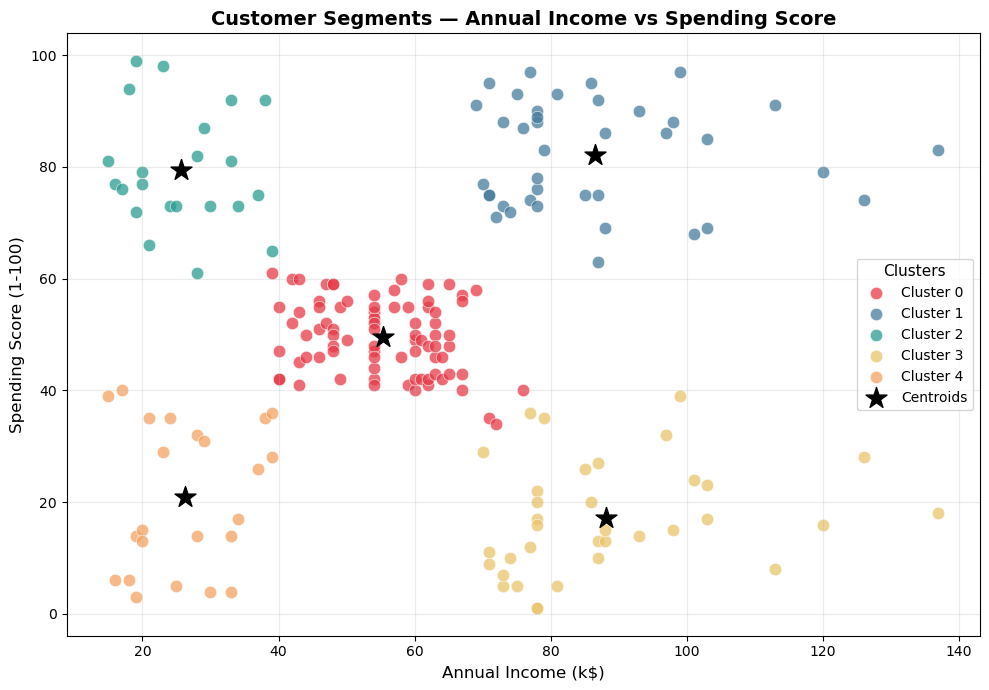

In [32]:
# --- 2D Cluster Scatter Plot ---
# Each color = one cluster; black stars = cluster centroids

cluster_colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

plt.figure(figsize=(10, 7))

# Plot each cluster separately so we can add a legend
for i in range(5):
    mask = labels_2d == i
    plt.scatter(X2[mask, 0], X2[mask, 1],
                color=cluster_colors[i], label=cluster_names[i],
                alpha=0.75, s=80, edgecolors='white', linewidth=0.5)

# Plot centroids in the original scale
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            s=250, c='black', marker='*', zorder=5, label='Centroids')

plt.title('Customer Segments — Annual Income vs Spending Score', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Clusters', fontsize=10, title_fontsize=11)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

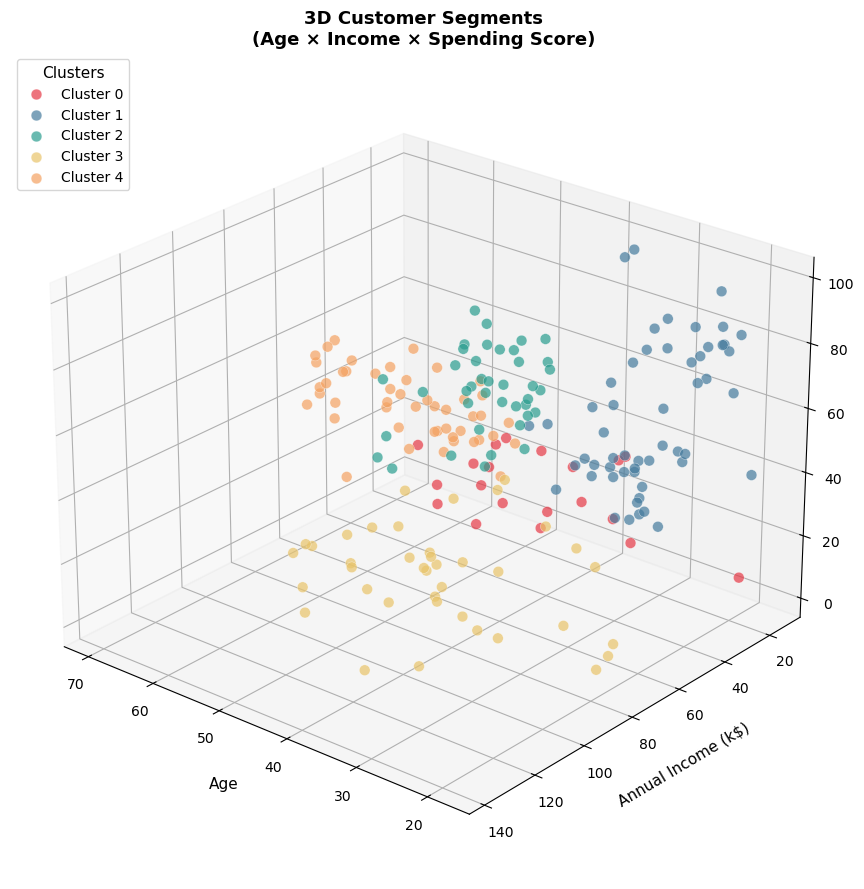

In [33]:
# --- 3D Cluster Scatter Plot ---
# Using Age, Annual Income, and Spending Score for a richer view

fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection='3d')

for i in range(5):
    mask = labels_3d == i
    ax.scatter(X3[mask, 0], X3[mask, 1], X3[mask, 2],
               color=cluster_colors[i], label=cluster_names[i],
               s=60, alpha=0.7, edgecolors='white', linewidth=0.3)

ax.set_title('3D Customer Segments\n(Age × Income × Spending Score)', fontsize=13, fontweight='bold')
ax.set_xlabel('Age', fontsize=11, labelpad=10)
ax.set_ylabel('Annual Income (k$)', fontsize=11, labelpad=10)
ax.set_zlabel('Spending Score (1-100)', fontsize=11, labelpad=10)
ax.legend(title='Clusters', fontsize=10, title_fontsize=11, loc='upper left')
ax.view_init(elev=25, azim=130)
plt.tight_layout()
plt.show()

In [34]:
# --- Cluster Profile Summary ---
# Show average values for each cluster — this tells us who each cluster IS

df['Cluster'] = labels_2d  # Use the 2D labels for profiling
profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
profile.index.name = 'Cluster'

print("Customer Profile per Cluster (Average Values):")
profile

Customer Profile per Cluster (Average Values):


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.7,55.3,49.5
1,32.7,86.5,82.1
2,25.3,25.7,79.4
3,41.1,88.2,17.1
4,45.2,26.3,20.9


---
## 💡 Step 10: Interpretation of Results

Based on the cluster visualization and the average values per cluster, we can identify **5 distinct customer segments**:

---

| Cluster | Description | Income | Spending | Strategy |
|---------|-------------|--------|----------|----------|
| 🔴 **Cluster 0** | **Careful Spenders** — High earners who spend conservatively | High | Low | Offer premium loyalty programs or exclusive deals |
| 🔵 **Cluster 1** | **Moderate Customers** — Average income and spending | Mid | Mid | Target with seasonal offers and discounts |
| 🟢 **Cluster 2** | **Target Customers** — High income AND high spending | High | High | Most valuable group — prioritize retention |
| 🟡 **Cluster 3** | **Budget Shoppers** — Low income but surprisingly high spending | Low | High | Engage with value deals, EMI options |
| 🟠 **Cluster 4** | **Low Engagement** — Low income and low spending | Low | Low | Re-engage with entry-level offers and incentives |

---

### ✅ Key Takeaways

1. **K-Means successfully segmented** 200 customers into 5 meaningful groups without any labeled data.
2. The **Elbow Method** helped us objectively choose K = 5 as the optimal number of clusters.
3. **Cluster 2 (high income + high spending)** is the most valuable customer segment for the business.
4. **Cluster 3 (low income + high spending)** is an interesting group that may indicate impulse buyers — worth studying further.
5. This segmentation can directly inform **targeted marketing campaigns**, improving ROI for the business.

---

### 🚀 Possible Next Steps
- Try **Hierarchical Clustering** and compare results with K-Means
- Use **Silhouette Score** to mathematically validate the optimal K
- Build a **customer recommendation system** based on the identified segments